# [LAB11] 지도학습 > 시계열 분석 > Prophet (BaseModel)

## #01. 라이브러리 개요

Facebook(현 Meta)에서 개발한 **시계열 예측 라이브러리**

- https://facebook.github.io/prophet/
- https://peerj.com/preprints/3190.pdf

### [1] Prophet의 목적
- 시간에 따른 데이터의 **추세(Trend)** 파악
- 반복되는 **계절성(Seasonality)** 분석
- 공휴일·이벤트 효과 반영
- 미래 값 예측

### [2] Prophet의 특징
- 결측치에 비교적 강함
- 불규칙한 간격 데이터 처리 가능
- 자동으로 추세 변화점(changepoint) 탐지
- 연/월/주 단위 계절성 자동 처리
- 파라미터 튜닝이 비교적 단순함

### [3] Prophet이 적합한 경우
- 매출 예측
- 방문자 수 예측
- 거래량 예측
- 트렌드 + 계절성이 존재하는 데이터

## #02. 준비작업

### [1] 패키지 참조

In [1]:
from hossam import *

from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np
from pandas import to_datetime, DataFrame
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
from sklearn.metrics import mean_absolute_error, mean_squared_error

### [2] 데이터 가져오기

어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)

In [2]:
origin = load_data("air_passengers")
origin.head()

어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)


,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


### [3] 데이터 프레임의 필드 이름 변경

prophet 라이브러리의 요구사항에 따라 날짜 필드의 이름을 `ds` 로, 데이터의 필드 이름을 `y` 로 변경해야 한다.

날짜의 데이터 타입은 `datetime` 형식이어야 한다.

> 날짜 변수가 인덱스가 아님에 유의

In [3]:
df_prophet = origin.rename(columns={"Month": "ds", "Passengers": "y"})
df_prophet["ds"] = to_datetime(df_prophet["ds"])
df_prophet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      144 non-null    datetime64[ns]
 1   y       144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


## #03. 시계열 데이터 준비

### [1] 데이터 분할

#### (1) 단순 비율 분할 (예: 80%/20%)

In [4]:
# 분할 비율
split_ratio = 0.8

# 분할 인덱스
split_idx = int(len(df_prophet) * split_ratio)

# 훈련 / 검증 데이터
train = df_prophet.iloc[:split_idx]
test = df_prophet.iloc[split_idx:]

print("Train 기간:", train["ds"].min(), "~", train["ds"].max())
print("Valid 기간:", test["ds"].min(), "~", test["ds"].max())

Train 기간: 1949-01-01 00:00:00 ~ 1958-07-01 00:00:00
Valid 기간: 1958-08-01 00:00:00 ~ 1960-12-01 00:00:00


#### (2) 날짜 기준 분할 (예: 특정 시점 이후를 검증)

In [5]:
# 검증 시작일 설정
split_date = "1958-08-01"

train = df_prophet[df_prophet["ds"] < split_date]
test = df_prophet[df_prophet["ds"] >= split_date]

print("Train 기간:", train["ds"].min(), "~", train["ds"].max())
print("Valid 기간:", test["ds"].min(), "~", test["ds"].max())

Train 기간: 1949-01-01 00:00:00 ~ 1958-07-01 00:00:00
Valid 기간: 1958-08-01 00:00:00 ~ 1960-12-01 00:00:00


### [2] 공휴일 데이터 설정

공휴일 효과를 기대할 수 없다면 이 과정은 생략할 수 있다.

#### Air Passengers Dataset의 특성

| 항목 | 내용 |
|------|------|
| 기간 | 1949-01 ~ 1960-12 |
| 빈도 | 월간(Monthly) |
| 단위 | 항공기 탑승객 수 |
| 지역 | 미국 항공 수요로 간주 |

#### 1950년대 미국 항공 수요에 영향을 주는 대표 시즌

| 시즌 | 월 | 근거 |
|------|-----|------|
| Independence Day | 7월 | 여름 휴가 성수기 |
| Thanksgiving | 11월 | 대규모 이동 |
| Christmas | 12월 | 연말 이동 |
| Summer Vacation | 6~8월 | 계절적 항공 수요 증가 |

#### 공휴일 데이터 생성하기

컬럼명이 고정되어 있다.

In [6]:
# 전체 연도 범위
years = range(1949, 1961)

holiday_list = []

for y in years:
    holiday_list.extend(
        [
            # Independence Day → 7월 효과
            {"holiday": "independence_day", "ds": f"{y}-07-01"},
            # Thanksgiving → 11월 효과
            {"holiday": "thanksgiving", "ds": f"{y}-11-01"},
            # Christmas → 12월 효과
            {"holiday": "christmas", "ds": f"{y}-12-01"},
            # Summer Vacation 시작 → 6월
            {"holiday": "summer_vacation", "ds": f"{y}-06-01"},
        ]
    )

holidays = DataFrame(holiday_list)
holidays["ds"] = to_datetime(holidays["ds"])

# 공휴일 효과 없음으로 설정 (다음 단계에서 설명)
holidays["lower_window"] = 0
holidays["upper_window"] = 0

holidays.head()

,holiday,ds,lower_window,upper_window
0,independence_day,1949-07-01,0,0
1,thanksgiving,1949-11-01,0,0
2,christmas,1949-12-01,0,0
3,summer_vacation,1949-06-01,0,0
4,independence_day,1950-07-01,0,0


#### 공휴일 효과

Prophet의 공휴일 효과는 하루짜리 충격(impulse)이 아니라 지정한 범위까지 영향이 확장되는 구조임.

| 파라미터 | 의미 |
|----------|------|
| `lower_window` | 공휴일 **이전** 며칠까지 효과를 줄 것인지 |
| `upper_window` | 공휴일 **이후** 며칠까지 효과를 줄 것인지 |

**예시**: 크리스마스 전후 4일간 holiday 효과 적용 (`lower_window=-2`, `upper_window=1`)

| 날짜 | 효과 적용 여부 |
|------|---------------|
| 12-23 | ✔ (−2일) |
| 12-24 | ✔ (−1일) |
| 12-25 | ✔ (당일) |
| 12-26 | ✔ (+1일) |
| 12-27 | ✖ |

#### 공휴일 효과 포함 샘플 코드

In [7]:
hd_test = DataFrame(
    {
        "holiday": "christmas",
        "ds": to_datetime(["2020-12-25"]),
        "lower_window": -2,
        "upper_window": 1,
    }
)
hd_test

,holiday,ds,lower_window,upper_window
0,christmas,2020-12-25,-2,1


#### 실습 데이터에 대한 공휴일 효과

Air Passengers처럼 월 단위 데이터에서는:

| 상황 | 권장 설정 |
|------|----------|
| 특정 하루 의미 없음 | `lower_window = 0` |
| 월 전체 영향 가정 | 월 첫날로 통일 |

- 월간 데이터에서 ±1일은 의미 없음
- 월 단위 모델에서는 1개월이 최소 단위

#### 언제 window를 크게 설정하나?

| 상황 | 예시 |
|------|------|
| 소비가 미리 증가 | 블랙프라이데이 |
| 명절 전 이동 증가 | 설날 |
| 명절 후 휴무 | 추석 연휴 |

## #03. 시계열 학습 모델 구현

### [1] 기본 모형 설정

| 파라미터 | 설정 가능 값 | 권장값 | 의미 |
|----------|-------------|--------|------|
| `growth` | `'linear'`, `'logistic'` | `'linear'` | 추세 증가 방식 |
| `changepoint_prior_scale` | 0.001 ~ 0.5 | 0.05 | 추세 변화 민감도 |
| `seasonality_mode` | `'additive'`, `'multiplicative'` | `'additive'` | 계절 효과 방식 |
| `yearly_seasonality` | True, False, 정수 | True | 연간 계절성 |
| `weekly_seasonality` | True, False, 정수 | 월별: False | 주간 계절성 |
| `daily_seasonality` | True, False, 정수 | False | 일간 계절성 |
| `holidays` | 공휴일 DataFrame | 도메인 기반 | 공휴일 효과 |
| `seasonality_prior_scale` | 0.01 ~ 20 | 10 | 계절성 강도 |
| `holidays_prior_scale` | 0.01 ~ 20 | 10 | 공휴일 효과 강도 |

#### 데이터 유형별 권장 조합

| 데이터 주기 | 추천 설정 |
|------------|----------|
| 월간 데이터 | yearly=True, weekly=False, daily=False |
| 일별 데이터 | yearly=True, weekly=True, daily=False |
| 시간 단위 데이터 | yearly=True, weekly=True, daily=True |

In [ ]:
model = Prophet(
    growth="linear",
    changepoint_prior_scale=0.05,
    seasonality_mode="additive",
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    holidays=holidays,
    seasonality_prior_scale=10,
    holidays_prior_scale=10,
)

model.fit(train)

10:47:36 - cmdstanpy - INFO - Chain [1] start processing
10:47:36 - cmdstanpy - INFO - Chain [1] done processing


### [2] 학습결과를 활용하여 예측

`periods` 는 예측할 기간 (일(`D`), 월(`M`) 단위 설정 가능 / 기본은 일단위)

In [9]:
future = model.make_future_dataframe(periods=len(test), freq="M")
forecast = model.predict(future)
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,christmas,christmas_lower,christmas_upper,holidays,holidays_lower,holidays_upper,independence_day,independence_day_lower,independence_day_upper,summer_vacation,summer_vacation_lower,summer_vacation_upper,thanksgiving,thanksgiving_lower,thanksgiving_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1949-01-01,109.538,67.645,112.915,109.538,109.538,-19.517,-19.517,-19.517,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-19.517,-19.517,-19.517,0.000,0.000,0.000,90.020
1,1949-02-01,111.674,62.619,104.842,111.674,111.674,-27.870,-27.870,-27.870,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-27.870,-27.870,-27.870,0.000,0.000,0.000,83.804
2,1949-03-01,113.604,95.530,139.591,113.604,113.604,4.277,4.277,4.277,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,4.277,4.277,4.277,0.000,0.000,0.000,117.881
3,1949-04-01,115.741,88.248,131.643,115.741,115.741,-5.547,-5.547,-5.547,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-5.547,-5.547,-5.547,0.000,0.000,0.000,110.194
4,1949-05-01,117.808,88.556,131.780,117.808,117.808,-6.674,-6.674,-6.674,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-6.674,-6.674,-6.674,0.000,0.000,0.000,111.135


### [3] 예측 결과에 대한 시각화

| 시각 요소 | 색상/형태 | 의미 | 해석 포인트 |
|-----------|----------|------|------------|
| Observed data points | 검은 점 | 실제 학습 데이터(train)의 관측값 | 예측선이 이 점들을 얼마나 잘 따라가는지 확인 |
| Forecast (yhat) | 파란색 실선 | 모델이 추정한 예측값 | 가장 가능성 높은 값 |
| Uncertainty interval | 반투명 파란 영역 | 예측의 신뢰 구간 | 넓을수록 불확실성이 큼 |
| Test(real) | 주황색 점선 | 검증 데이터의 실제값 | 파란 실선과 가까울수록 예측 성능 양호 |

- **모델 적합 확인 (Train 구간)**: 검은 점과 파란 선이 잘 겹치면 적합 양호, 큰 편차 지속 시 언더피팅 가능
- **일반화 확인 (Test 구간)**: 검은 점선(test)이 파란 선과 가깝다면 예측 성능 양호, 지속적으로 벗어나면 편향 발생

**불확실성 해석**: 신뢰 구간이 급격히 넓어지면 장기 예측 / 변동성 증가 / 데이터 부족 가능성

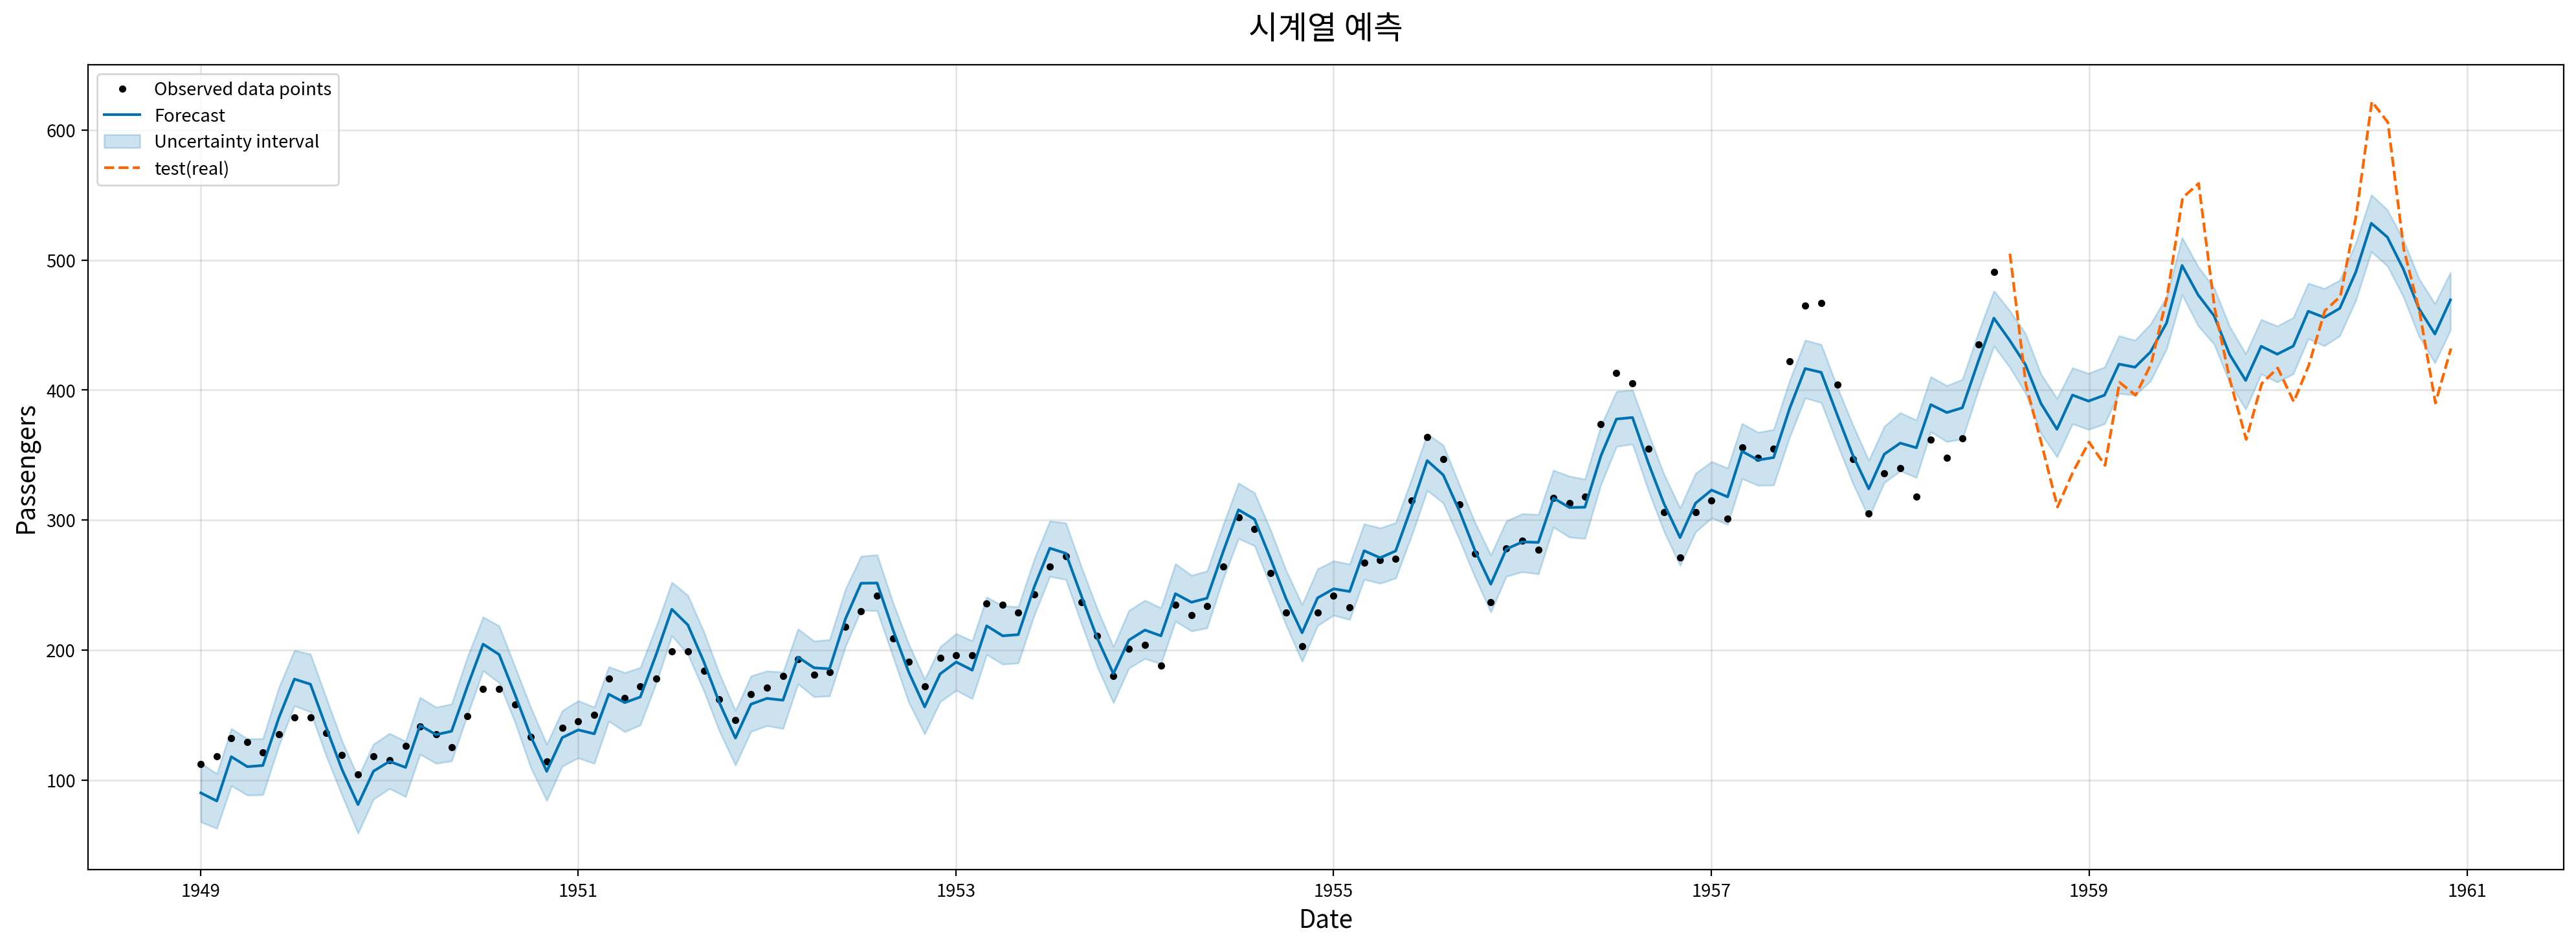

In [10]:
fig = model.plot(
    forecast, figsize=(20, 7), xlabel="Date", ylabel="Passengers", uncertainty=True
)
ax = fig.gca()
ax.set_title("시계열 예측")

# 실제 검증 데이터는 직접 추가한다.
sb.lineplot(
    data=test, x="ds", y="y", ax=ax, color="#ff6600", linestyle="--", label="test(real)"
)

plt.show()
plt.close()

### [4] changepoint를 추가한 시각화

`changepoint` - Trend가 변화하는 지점

- `fig.gca()` : 시계열 그래프
- `model` : 미리 만들어준 Prophet 객체
- `forecast` : predict 결과

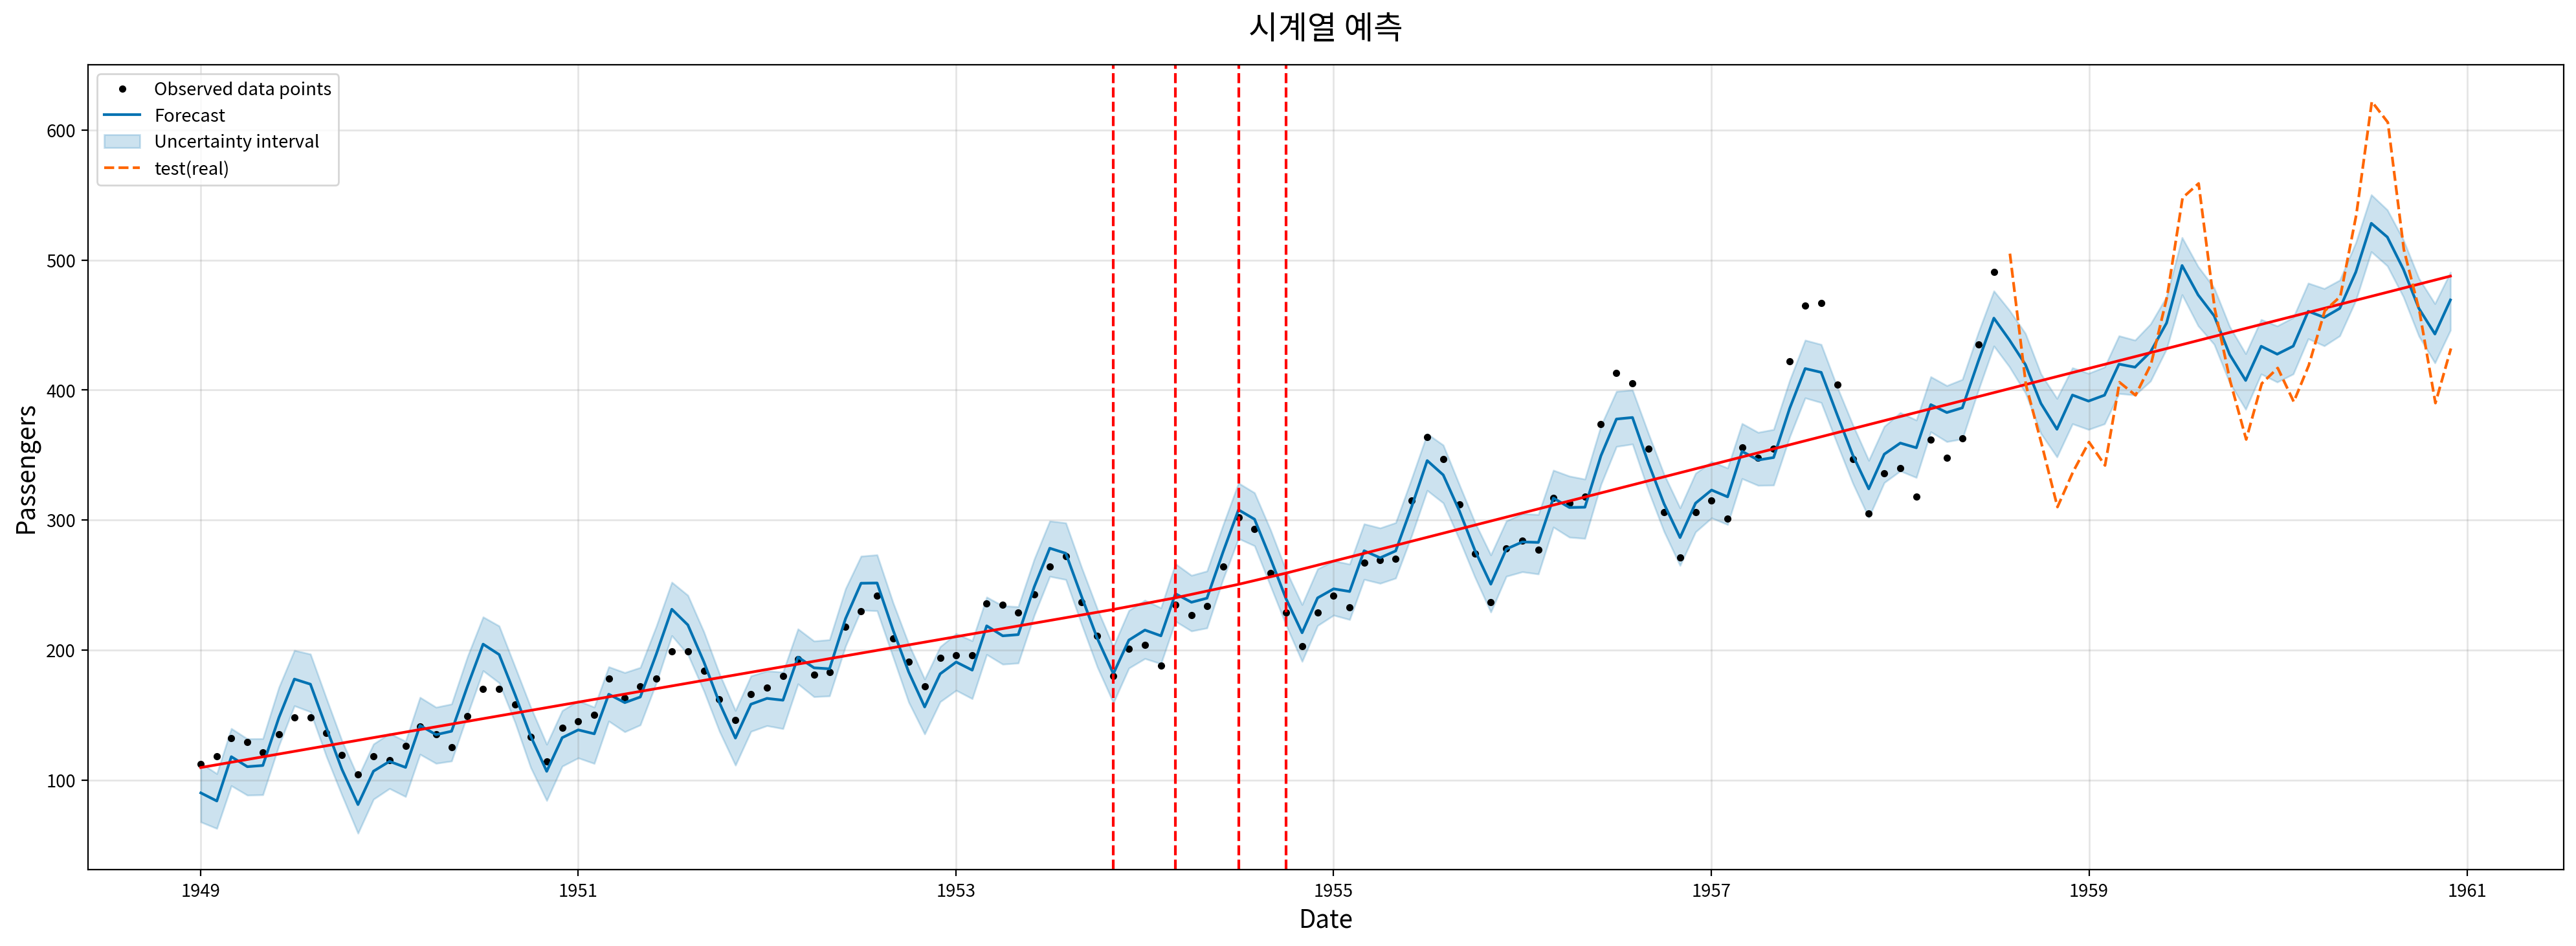

In [11]:
fig = model.plot(
    forecast, figsize=(20, 7), xlabel="Date", ylabel="Passengers", uncertainty=True
)
ax = fig.gca()
add_changepoints_to_plot(ax, model, forecast)

ax.set_title("시계열 예측")
sb.lineplot(
    data=test, x="ds", y="y", ax=ax, color="#ff6600", linestyle="--", label="test(real)"
)

plt.show()
plt.close()

### [5] 모델이 갖는 컴포넌트 확인 (성분분해)

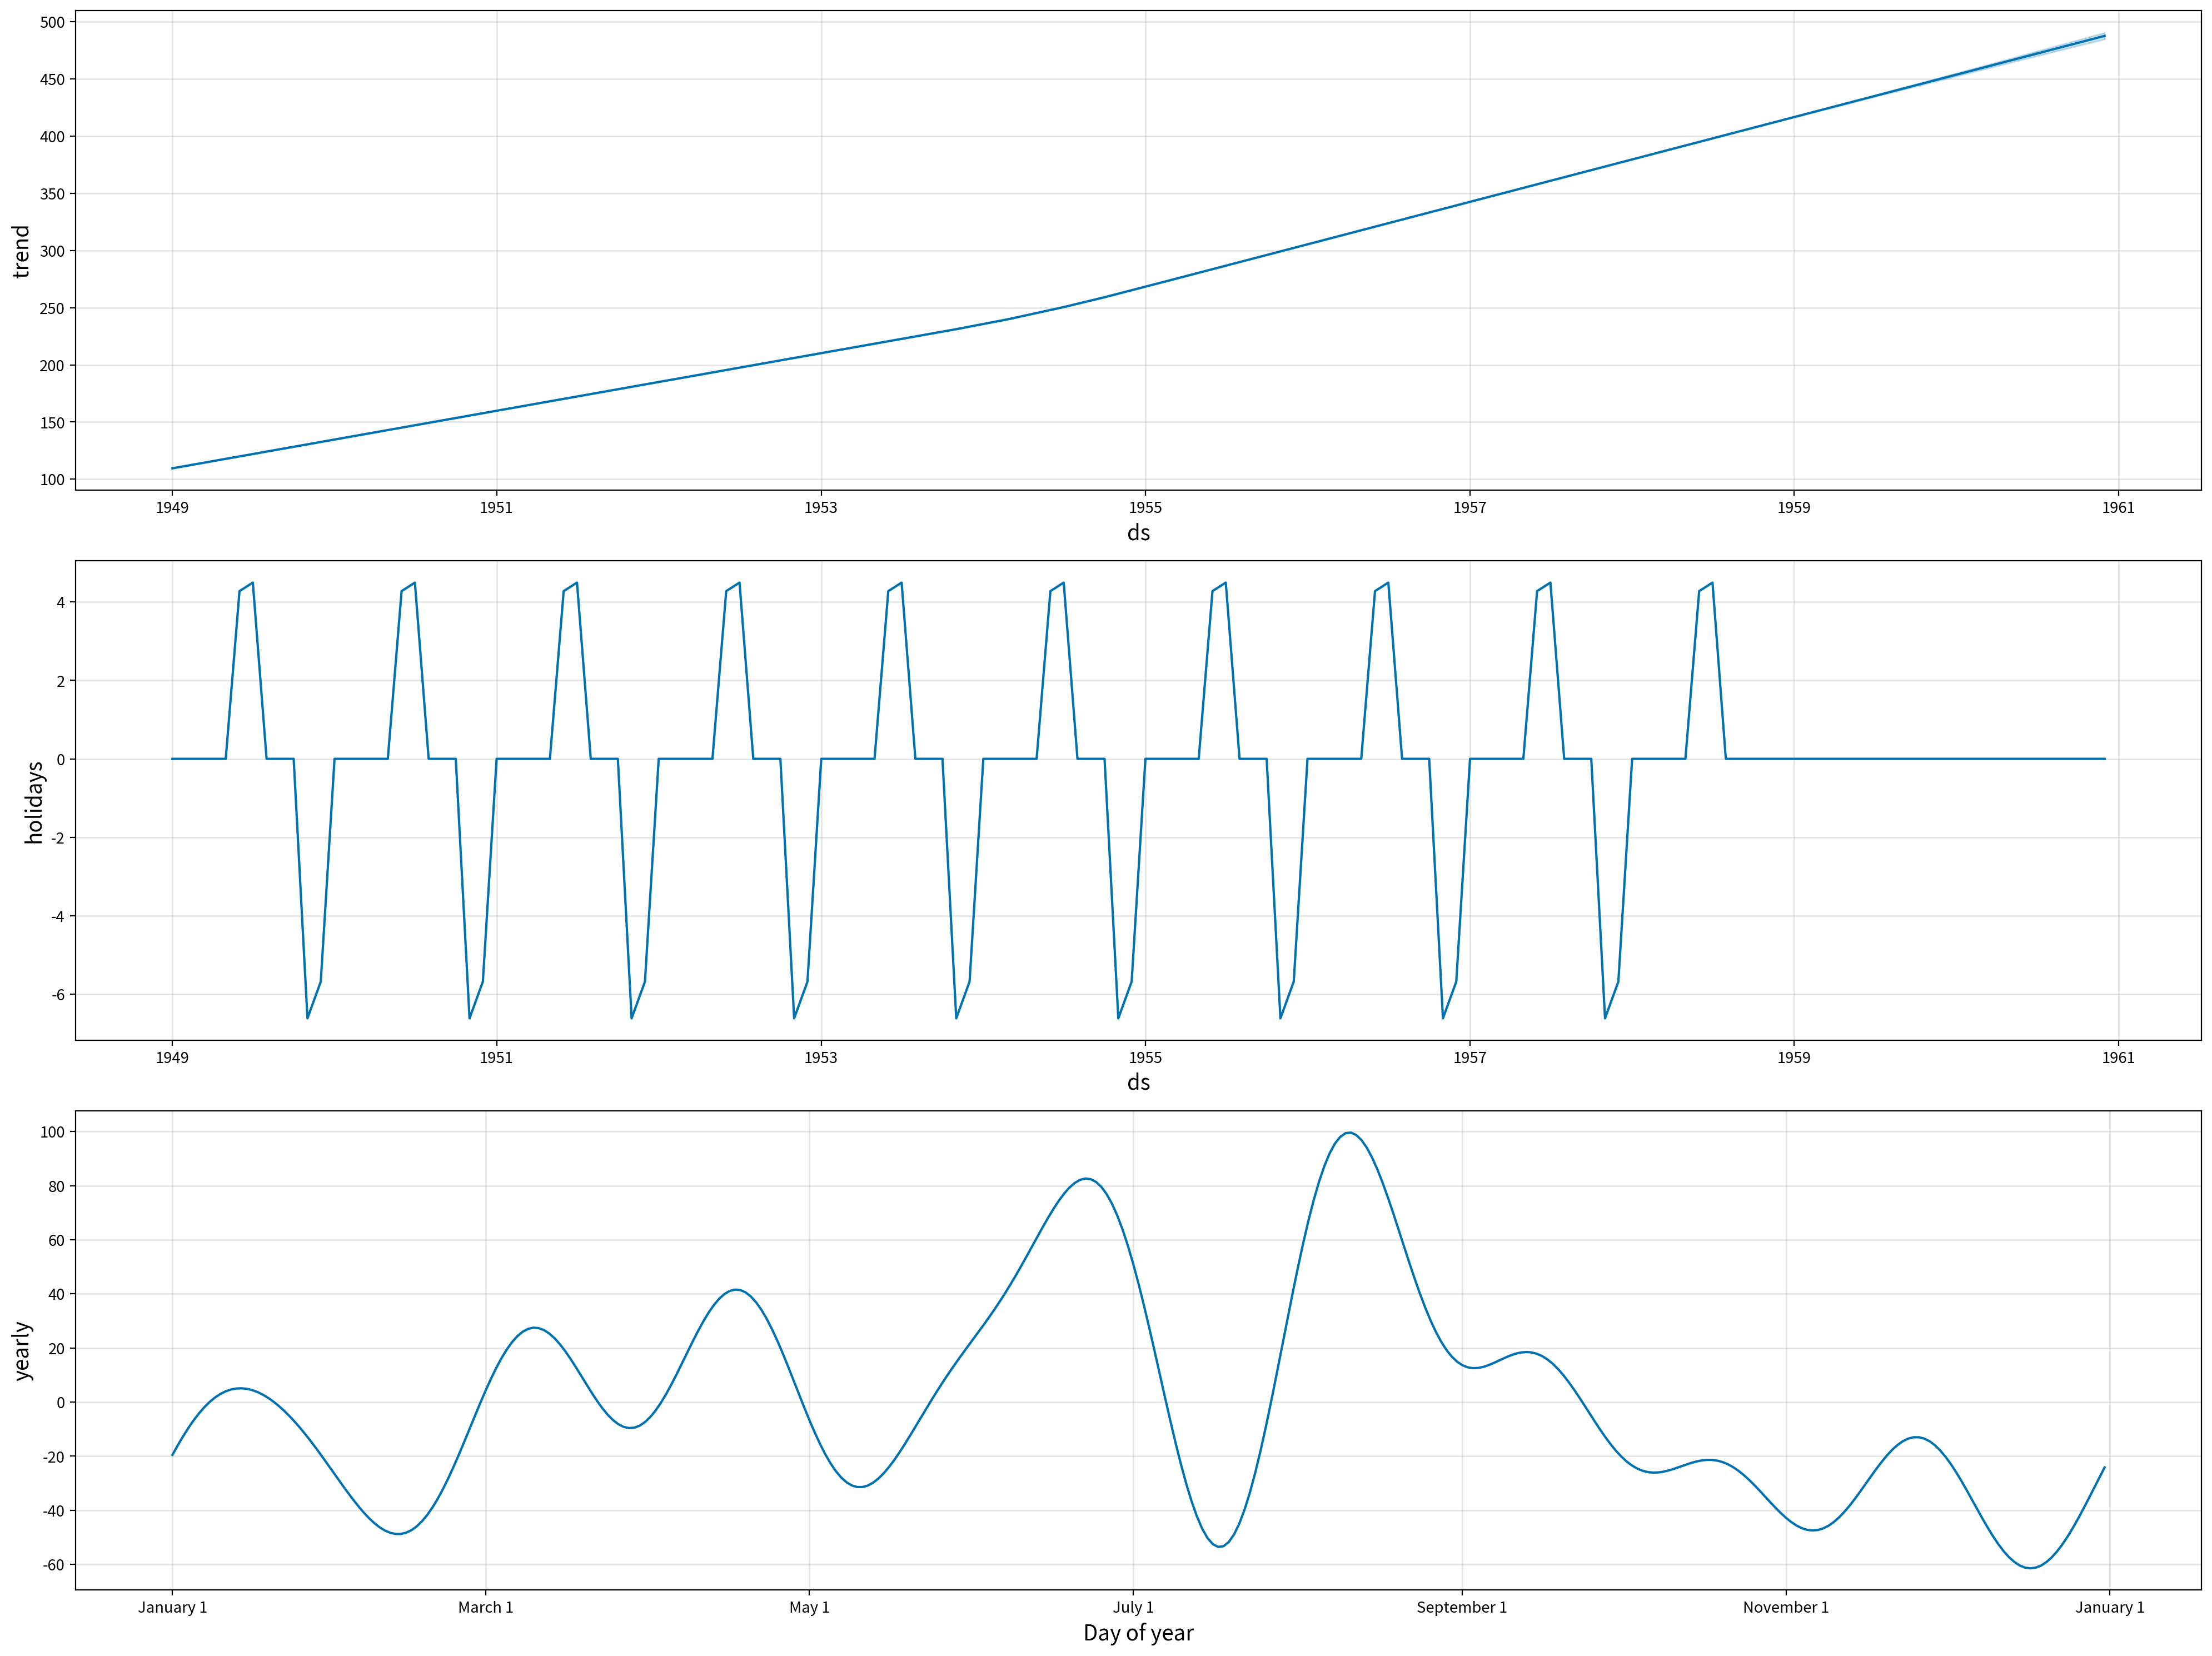

In [12]:
fig = model.plot_components(forecast, figsize=(20, 15))
ax = fig.gca()
plt.show()
plt.close()

## #04. 성능평가

### 실제 y값과 예측 y값 얻기

In [13]:
y = test["y"].values
y

array([505, 404, 359, 310, 337, 360, 342, 406, 396, 420, 472, 548, 559,
       463, 407, 362, 405, 417, 391, 419, 461, 472, 535, 622, 606, 508,
       461, 390, 432])

In [14]:
yhat = forecast["yhat"].values[-len(test) :]
yhat

array([438.63917692, 419.61318436, 389.72625815, 369.8669195 ,
       396.17536784, 391.53191933, 396.06555393, 419.98751951,
       417.61482918, 429.40084989, 451.64055858, 495.86742321,
       473.24833904, 457.13173799, 427.3823127 , 407.42212537,
       433.73342902, 427.64798779, 433.8255703 , 460.65333199,
       455.92675973, 462.88563281, 490.8103065 , 528.34481687,
       517.73683825, 493.05367733, 462.83660633, 443.15783319,
       469.35060735])

### Test(Validation) 성능 계산

In [15]:
valid_mae = mean_absolute_error(y, yhat)
valid_mse = mean_squared_error(y, yhat)
valid_rmse = np.sqrt(valid_mse)

### Train 성능 계산

In [16]:
# train 구간 예측값 추출
yhat_train = forecast["yhat"].values[: -len(test)]
y_train = train["y"].values

train_mae = mean_absolute_error(y_train, yhat_train)
train_mse = mean_squared_error(y_train, yhat_train)
train_rmse = np.sqrt(train_mse)

### 과적합 판단

| 조건 | 해석 |
|------|------|
| Valid RMSE ≈ Train RMSE | 일반화 양호 |
| Valid RMSE > Train RMSE (차이 큼) | 과적합 의심 |
| 둘 다 큼 | 언더피팅 가능 |

In [17]:
rmse_gap = valid_rmse - train_rmse
gap_ratio = rmse_gap / train_rmse

if gap_ratio > 0.2:
    overfit_flag = "과적합 의심"
elif gap_ratio > 0.1:
    overfit_flag = "약한 과적합 가능성"
else:
    overfit_flag = "일반화 양호"

### 최종 성능표 생성

In [18]:
result = DataFrame(
    {
        "Train_MAE": [train_mae],
        "Train_RMSE": [train_rmse],
        "Valid_MAE": [valid_mae],
        "Valid_RMSE": [valid_rmse],
        "RMSE_차이": [rmse_gap],
        "차이비율": [gap_ratio],
        "과적합의심여부": [overfit_flag],
    }
)
result

,Train_MAE,Train_RMSE,Valid_MAE,Valid_RMSE,RMSE_차이,차이비율,과적합의심여부
0,13.177,16.933,36.680,44.692,27.759,1.639,과적합 의심


### 시계열 분석에서의 과적합과 일반 ML에서의 과적합 차이

| 구분 | 일반 ML | 시계열 |
|------|---------|--------|
| 데이터 구조 | 독립 샘플 | 시간 의존성 존재 |
| 검증 방식 | 랜덤 분할 | 시간 순서 유지 |
| 과적합 의미 | 훈련만 잘 맞음 | 과거만 잘 맞고 미래 실패 |

> **"과거 패턴을 지나치게 세밀하게 따라간 결과 미래 예측이 불안정해지는 현상"**

시계열은 기본적으로 미래로 갈수록 불확실성이 증가하고 구조 변화(regime change)가 가능하기 때문에 완벽한 일반화 개념이 약함. 따라서 과적합 여부는 "절대적 판단"이 아니라 **"예측 안정성 점검"** 개념에 가까움.

#### 실무적 해석 포인트

| 항목 | 중요성 |
|------|--------|
| 예측 방향성 | 상승/하락 추세 맞는가 |
| 신뢰구간 안정성 | 불확실성 과도하게 넓은가 |
| 구조 일관성 | 모델이 설명 가능한가 |